In [1]:
using LinearAlgebra, QuantumOptics, DifferentialEquations, Plots, SparseArrays, JLD2, FileIO

## 2 atoms Encoding

### Initialization

In [2]:
const a = ComplexF64[1,0,0];        #Qubit state |0>
const b = ComplexF64[0,1,0];        #Qubit state |1>
const r = ComplexF64[0,0,1];       #Qubit state |r>

α = 1
β = sqrt(1 - α^2)
ψ_1 = α .* b + β .* a; #Qubit state |ψ_1>
# ψ_1 = b
ψ_2 = a

ψ_a_op = Ket(NLevelBasis(3), ψ_1) ⊗ Ket(NLevelBasis(3), ψ_2)
ρ0_op = ψ_a_op ⊗ dagger(ψ_a_op);

In [3]:
function full_operator(gate,sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    basis = NLevelBasis(3)
    identity = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis, 3, 3) 
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:2]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function Precomputed_ops()
    basis = NLevelBasis(3)
    σx_1r = transition(basis, 2, 3) + transition(basis, 3, 2) #|1> <-> |r>
    σx_0r = transition(basis, 1, 3) + transition(basis, 3, 1) #|0> <-> |r>
    n_r = transition(basis, 3, 3) #|r> <-> |r>
    I2 = transition(basis, 1, 1) + transition(basis, 2, 2) + transition(basis,3,3) #|0> <-> |0> + |1> <-> |1>

    σx_1r_atom1 = σx_1r ⊗ I2
    σx_1r_atom2 = I2 ⊗ σx_1r
    σx_0r_atom2 = I2 ⊗ σx_0r
    n_r_atom2 = I2 ⊗ n_r
    nn_r = n_r ⊗ n_r

    return (σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r)
end

const ops = Precomputed_ops();


function Ht(t)
    # if t<10.0
    #     Ω1 = 0.0
    # else
    #     Ω1 = 1.0
    # end

    σx_1r_atom1, σx_1r_atom2, σx_0r_atom2, n_r_atom2, nn_r = ops

    H = Ω1/2 .* σx_1r_atom1 + Ω2/2 .* (σx_0r_atom2 + σx_1r_atom2) + Δ_0 .* n_r_atom2 + V_nn .* nn_r  #+ σx_1r_atom2) +10 .* n_r_atom2
        # -5 .* nn_r

    return H
end

function f(t,ρ)
    H = Ht(t)
    J = Operator[]
    return (H, J, dagger.(J))
end


f (generic function with 1 method)

In [4]:
const Δ_0 = -1000
const Ω1 = 5.0
const Ω2 = 5.0
const γ_Decay = 0.0
const γ_dephase = 0.0
const V_nn = 1000;

In [5]:
tspan = [0.0:0.1:(100);];
tout, sol = timeevolution.master_dynamic(tspan, ρ0_op, f; alg=ROCK4());

In [6]:
pop0_atom1 = []
pop1_atom1 = []
popr_atom1 = []
popr_atom2 = []
pop0_atom2 = []
pop1_atom2 = []

k = NLevelBasis(3)
n0 = transition(k, 1, 1)
n1 = transition(k, 2, 2)
nr = transition(k, 3, 3)
I2 = transition(k, 1, 1) + transition(k, 2, 2) + transition(k, 3, 3)

n0_atom1 = (n0 ⊗ I2)
n0_atom2 = (I2 ⊗ n0)
n1_atom1 = (n1 ⊗ I2)
n1_atom2 = (I2 ⊗ n1)
nr_atom1 = (nr ⊗ I2)
nr_atom2 = (I2 ⊗ nr)


for ρ in sol
    push!(popr_atom1, real(tr(nr_atom1*ρ)))
    push!(pop0_atom1, real(tr(n0_atom1*ρ)))
    push!(pop1_atom1, real(tr(n1_atom1*ρ)))
    push!(popr_atom2, real(tr(nr_atom2*ρ)))
    push!(pop0_atom2, real(tr(n0_atom2*ρ)))
    push!(pop1_atom2, real(tr(n1_atom2*ρ)))
end

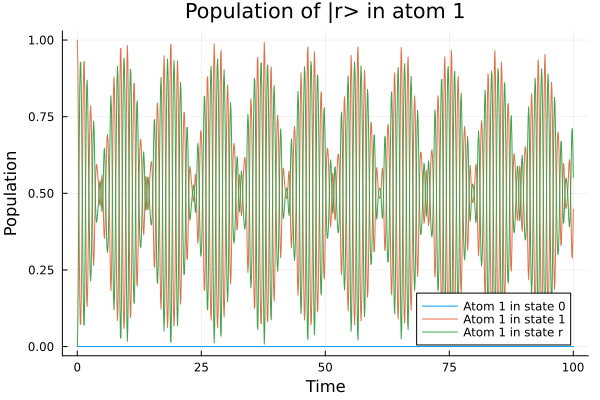

In [7]:
plot(tspan,pop0_atom1, label="Atom 1 in state 0", title="Population of |0> in atom 1", xlabel="Time", ylabel="Population",legend=:bottomright)
plot!(tspan,pop1_atom1, label="Atom 1 in state 1", title="Population of |1> in atom 1", xlabel="Time", ylabel="Population")
plot!(tspan,popr_atom1, label="Atom 1 in state r", title="Population of |r> in atom 1", xlabel="Time", ylabel="Population")


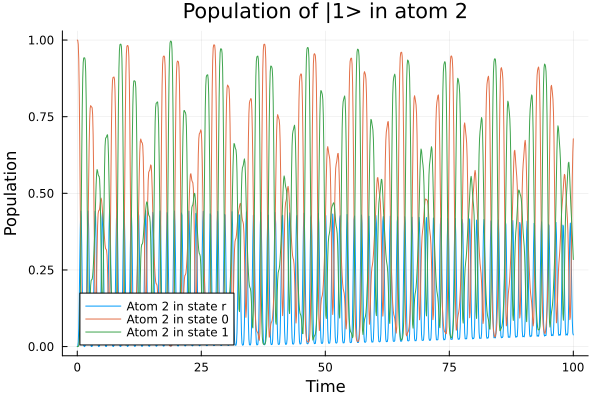

In [8]:
plot(tspan,popr_atom2, label="Atom 2 in state r", title="Population of |r> in atom 2", xlabel="Time", ylabel="Population",legend=:bottomleft)
plot!(tspan,pop0_atom2, label="Atom 2 in state 0", title="Population of |0> in atom 2", xlabel="Time", ylabel="Population")
plot!(tspan,pop1_atom2,label="Atom 2 in state 1", title="Population of |1> in atom 2", xlabel="Time", ylabel="Population")